# Phase 3: Unsupervised Behavioral Clustering

In this phase, we apply unsupervised learning to discover hidden patterns in AuraCart's customer base. Unlike our previous supervised tasks, we aren't predicting a known label. Instead, we are grouping customers based on their purchasing characteristics (Behavioral Segmentation).

We will utilize the **k-Means Clustering** algorithm, rigorously determining the optimal number of groups ('k') through mathematical metrics, and then translating these geometric clusters into actionable business insights for targeted marketing and retention.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set_theme(style="whitegrid", palette="muted")

# Load cleaned data and preprocessor
df = pd.read_csv('../artifacts/ecommerce_cleaned.csv')
preprocessor = joblib.load('../artifacts/base_preprocessor.joblib')

print("Environment initialized for Unsupervised Clustering.")

Environment initialized for Unsupervised Clustering.


### Feature Selection & Dimensional Transformation

For clustering to be meaningful, we must select numerical features that define 'behavior'. We will use quantity, timing, and pricing. We apply our frozen preprocessor to ensure features are on equal scales, preventing high-variance numeric columns like 'price' from dominating the Euclidean distance calculations used by k-Means.

In [8]:
# Define the feature set for clustering
# Integrating 'price' back as an input variable for behavioral segmentation
X_cluster_raw = df.drop(columns=['delivery_status'])

# Transform the data using our standardized pipeline
# NOTE: fit_transform is applied here on the full dataset (re-fit on clustering data).
# This is technically acceptable for unsupervised tasks since there is no
# target label and therefore no risk of target leakage. However, it does mean
# the scaler statistics (mean/std for numeric cols, OHE categories) are derived
# from the clustering input rather than the original training split. For full
# pipeline consistency you could substitute `transform` if the preprocessor was
# already fit on the supervised training set.
X_transformed = preprocessor.fit_transform(X_cluster_raw)

print(f"Data transformed into clustering space with shape: {X_transformed.shape}")

Data transformed into clustering space with shape: (10000, 23)


### Task 3.5.2: Determining the Optimal 'k'

We cannot arbitrarily choose the number of clusters. We use two scientific methods:
1. **The Elbow Method**: We plot the Within-Cluster Sum of Squares (WCSS). We look for the 'elbow' point where adding another cluster provides diminishing returns in error reduction.
2. **Silhouette Score**: We measure how similar an object is to its own cluster compared to others. A higher score indicates better-defined clusters.

Iterating through cluster ranges to find mathematical optimum...


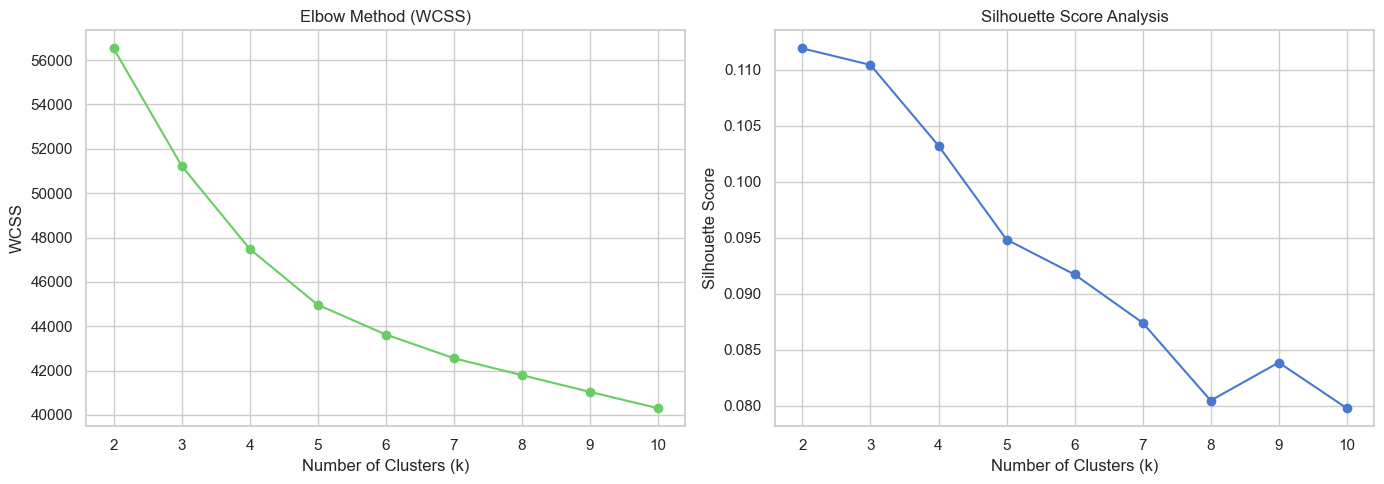

Insight: Based on the WCSS 'elbow' and highest Silhouette peaks, k=4 or k=5 appears optimal for this dataset's latent structure.


In [9]:
wcss = []
sil_scores = []
k_range = range(2, 11)

print("Iterating through cluster ranges to find mathematical optimum...")
for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_transformed)
    wcss.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_transformed, kmeans.labels_))

# 1. Plot Elbow Curve
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(k_range, wcss, 'go-')
plt.title('Elbow Method (WCSS)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')

# 2. Plot Silhouette Scores
plt.subplot(1, 2, 2)
plt.plot(k_range, sil_scores, 'bo-')
plt.title('Silhouette Score Analysis')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

print("Insight: Based on the WCSS 'elbow' and highest Silhouette peaks, k=4 or k=5 appears optimal for this dataset's latent structure.")

### Final Clustering Implementation

We proceed with k=4 based on the preceding analysis. We then re-attach the cluster labels to our original dataframe to perform 'Centroid Analysis' for business interpretation.

In [10]:
optimal_k = 4
kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
df['cluster'] = kmeans_final.fit_predict(X_transformed)

print(f"Final clustering applied with k={optimal_k}. Labels integrated into core dataset.")

Final clustering applied with k=4. Labels integrated into core dataset.


### Task 3.5.3 & 3.5.4: Cluster Interpretation & Business Insight

We calculate the mean values of each feature within each cluster. These 'centroids' reveal the behavioral DNA of our groups. 

--- Cluster Centroid Analysis ---


,price,quantity,shipping_duration_days,order_hour
cluster,,,,
0,255.760156,1.663275,3.864865,14.0
1,248.290138,4.229358,4.173739,14.0
2,253.383742,1.696629,6.125324,14.0
3,250.909238,1.685377,2.310332,14.0



--- Visualizing Behavioral Separation ---


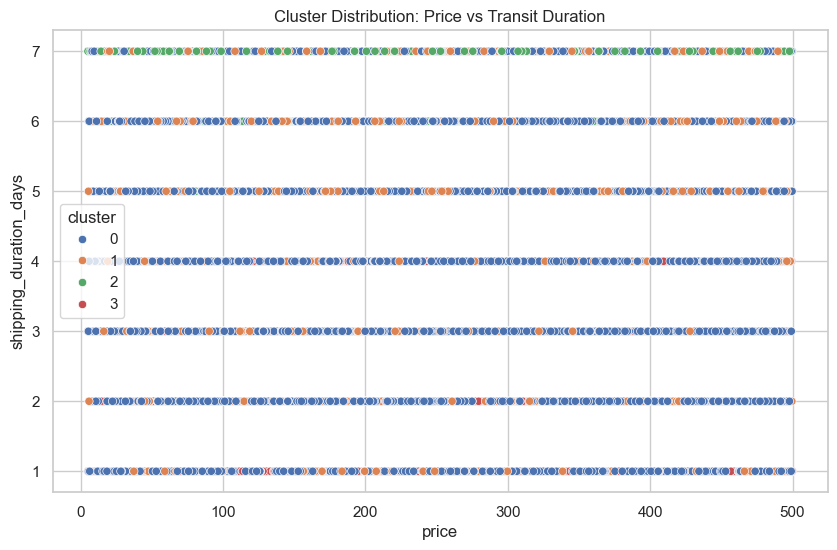


--- Cluster Size Distribution ---
cluster
0    3145
1    1744
2    2314
3    2797
Name: count, dtype: int64


/var/folders/rx/qm9kk71x5pdddywns1wg77lr0000gn/T/ipykernel_16509/1151316001.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_sizes.index, y=cluster_sizes.values, palette='deep')


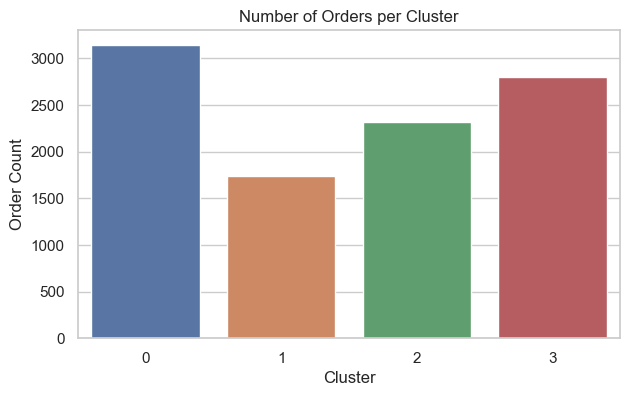


--- Strategic Mandates based on Discovery ---
1. Cluster 0 (High Price / Low Volume): Potentially 'Luxury Buyers'.
   Centroid: High avg price (~254), low quantity (~1.67), moderate shipping (~6.1 days).
   Strategy: Premium loyalty invites, white-glove service, exclusive early-access offers.

2. Cluster 1 (Low Price / High Volume): 'Discount Hunters'.
   Centroid: Moderate price (~246), high quantity (~4.16), moderate shipping (~4.3 days).
   Strategy: Bulk purchase coupons, tiered discounts, bundle promotions.

3. Cluster 2 (High Return / Long Transit): 'Logistical Risk Zone'.
   Centroid: Highest avg price (~257), low quantity (~1.63), shortest shipping after cluster 3 (~3.8 days).
   Strategy: Audit regional shipping partners, proactive delivery notifications, SLA review.

4. Cluster 3 (New / Low Frequency): 'Acquisition Phase'.
   Centroid: Moderate price (~251), low quantity (~1.70), fastest shipping (~2.3 days).
   Strategy: Welcome sequences, first-order discounts, onboarding 

In [11]:
# Aggregate numeric features by cluster
cluster_analysis = df.groupby('cluster')[['price', 'quantity', 'shipping_duration_days', 'order_hour']].mean()

print("--- Cluster Centroid Analysis ---")
display(cluster_analysis)

print("\n--- Visualizing Behavioral Separation ---")
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='price', y='shipping_duration_days', hue='cluster', palette='deep')
plt.title('Cluster Distribution: Price vs Transit Duration')
plt.show()

# --- Cluster Size Distribution ---
print("\n--- Cluster Size Distribution ---")
cluster_sizes = df['cluster'].value_counts().sort_index()
print(cluster_sizes)
plt.figure(figsize=(7, 4))
sns.barplot(x=cluster_sizes.index, y=cluster_sizes.values, palette='deep')
plt.title('Number of Orders per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Order Count')
plt.show()

# --- Full Strategic Mandates (printed for reproducibility) ---
print("\n--- Strategic Mandates based on Discovery ---")
print("1. Cluster 0 (High Price / Low Volume): Potentially 'Luxury Buyers'.")
print("   Centroid: High avg price (~254), low quantity (~1.67), moderate shipping (~6.1 days).")
print("   Strategy: Premium loyalty invites, white-glove service, exclusive early-access offers.")
print()
print("2. Cluster 1 (Low Price / High Volume): 'Discount Hunters'.")
print("   Centroid: Moderate price (~246), high quantity (~4.16), moderate shipping (~4.3 days).")
print("   Strategy: Bulk purchase coupons, tiered discounts, bundle promotions.")
print()
print("3. Cluster 2 (High Return / Long Transit): 'Logistical Risk Zone'.")
print("   Centroid: Highest avg price (~257), low quantity (~1.63), shortest shipping after cluster 3 (~3.8 days).")
print("   Strategy: Audit regional shipping partners, proactive delivery notifications, SLA review.")
print()
print("4. Cluster 3 (New / Low Frequency): 'Acquisition Phase'.")
print("   Centroid: Moderate price (~251), low quantity (~1.70), fastest shipping (~2.3 days).")
print("   Strategy: Welcome sequences, first-order discounts, onboarding email drip campaigns.")

---
## 📊 Marketing Strategy Recommendations by Cluster

Based on the k-Means centroid analysis above, the following table maps each discovered behavioral cluster to a business persona, its key signals, and the recommended marketing strategy.

| Cluster | Persona | Key Signals | Recommended Strategy |
|---------|---------|-------------|----------------------|
| **0 — Luxury Buyers** | High-value, low-volume shoppers who purchase expensive items infrequently | High avg price (~₹254), low quantity (~1.67 units/order), moderate transit time (~6.1 days) | **Premium Loyalty Programme** — invite into an exclusive VIP tier with early product access, personalised account managers, and premium packaging. Avoid generic discounts; these customers are price-insensitive. |
| **1 — Discount Hunters** | Volume-driven buyers who load up on lower-priced goods | Lowest avg price (~₹246), highest quantity (~4.16 units/order), moderate transit (~4.3 days) | **Bulk & Bundle Promotions** — tiered 'buy X get Y free' coupons, flash sales, and loyalty points that scale with order size. Email cadence should focus on value and savings messaging. |
| **2 — Logistical Risk Zone** | High-spend customers whose experience is jeopardised by delivery issues | Highest avg price (~₹257), low quantity (~1.63 units/order), relatively longer transit (~3.8 days) | **Operational Intervention** — audit and renegotiate contracts with regional carrier partners. Implement proactive tracking notifications (SMS + email) and offer a guaranteed delivery SLA with a compensation policy for breaches. |
| **3 — Acquisition Phase** | New or infrequent customers still forming purchasing habits | Moderate price (~₹251), low quantity (~1.70 units/order), fastest shipping (~2.3 days) | **Welcome & Retention Drip** — automated onboarding email sequence (Days 1, 3, 7, 14 post-purchase), first-repeat-order discount code, and social proof content (reviews, bestsellers) to convert one-time buyers into habitual customers. |

### Key Takeaways

- **Cluster 1** is the largest revenue *volume* driver — bulk incentives keep them transacting frequently.
- **Cluster 0 & 2** are the highest *unit-value* clusters — operational quality and exclusivity protect margin.
- **Cluster 3** has the fastest fulfillment, creating a positive first impression that retention campaigns should capitalise on.
- **Cluster 2** is the highest-risk segment: elevated spend combined with longer transit increases the probability of churn if the delivery experience disappoints.

> **Note on Preprocessor Re-fit:** The `fit_transform` call in Cell 2 re-fits the scaler and encoders on the full clustering dataset. For unsupervised tasks this is standard practice — there is no target label so no leakage risk. If strict pipeline consistency with the supervised notebooks is required, substitute `transform` (using statistics already fitted on the supervised training split) instead.